# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Fit single neuron level coupling

In [346]:
### Get the id of neurons that are classified as cross-pop
stimulus_condition_id = [275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270]
cross_pop_list_all = {}
probe_list = V1.selected_probes
for target_probe in probe_list:
    cross_pop_list = []
    cross_pop_conditions = {}
    for neuron in membership[0].index:
        if membership[1].loc[neuron]['probe'] == target_probe:
            for i, member in enumerate(membership):
                if member.loc[neuron]['group_id'] == 0:
                    if condition_ids[i] in stimulus_condition_id:
                        if neuron not in cross_pop_conditions:
                            cross_pop_list.append(neuron)
                            cross_pop_conditions[neuron] = [condition_ids[i]]
                        else:
                            cross_pop_conditions[neuron].append(condition_ids[i])
    major_cross_pop_list = []
    for neuron in cross_pop_list:
        if len(cross_pop_conditions[neuron])>= 14:
            major_cross_pop_list.append(neuron)
    cross_pop_list_all[target_probe] = major_cross_pop_list

In [347]:
cross_pop_list_all

{'probeA': [951815173, 951815207, 951815269, 951815231, 951815403],
 'probeB': [951807276, 951807379, 951807411, 951807673, 951807941],
 'probeC': [951801108, 951801369, 951801604, 951801755],
 'probeD': [951810983, 951811026, 951811015, 951811873],
 'probeE': [951819135, 951819593, 951819836],
 'probeF': [951804050, 951804082, 951804331, 951804336]}

In [348]:
spike_train_ind_dict = {}
for target_probe in probe_list:
    for neuron in cross_pop_list_all[target_probe]:
        # Get spike train of the neuron first
        spike_train_ind = np.zeros((V1.nt+V1.npadding, V1.spike_train.shape[1]))
        for itrial in range(V1.spike_train.shape[1]):
            spike_train_ind[:,itrial] = V1.spike_train.loc[neuron, V1.spike_train.columns[itrial]]
        spike_train_ind_dict[neuron] = spike_train_ind
    

In [349]:
neuron = 951810863
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 1e-2

### Stationary
select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
for j, input_probe in enumerate(probe_list):
    for input_neuron in cross_pop_list_all[input_probe]:
        spike_train_ind = spike_train_ind_dict[input_neuron]
        model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], 
                                    **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit(spike_train_ind[:,select_trials], 
                                           method='mine', 
                                           verbose=False, 
                                           penalty=penalty, 
                                           no_penalty_term_penalty=1e-2)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


5.020342621264241


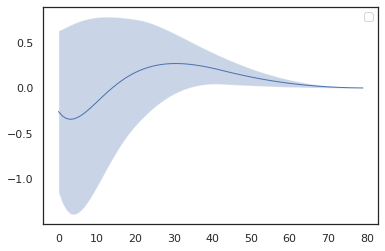

In [350]:
to_look = 4
GLM.plot_GLM_one_effect(model_stationary, to_look)
print(np.sum(model_stationary.get_filter()[to_look]))

In [351]:
from collections import defaultdict
strength_stationary = defaultdict(list)
strength_running = defaultdict(list)

for i, target_probe in enumerate(probe_list):
    for neuron in tqdm(cross_pop_list_all[target_probe]):

        max_iter = 10
        tau = 15
        coupling_filter_params = {'peaks_max':10, 'num':3, 'nonlinear':0.5}
        num_basis_baseline = 20
        penalty = 1e-2
        
        ### Stationary
        select_trials = V1.stationary_trial_index
        model_stationary = GLM.PP_GLM(dataset=V1, 
                               select_trials=select_trials, 
                               membership=membership, 
                               condition_ids=condition_ids)
        model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                spike_train_ind = spike_train_ind_dict[input_neuron]
                model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], 
                                            **coupling_filter_params, apply_no_penalty=False)
        model_stationary.add_effect('trial_coef')
        model_stationary.fit(spike_train_ind[:,select_trials], 
                               method='mine', 
                               verbose=False, 
                               penalty=penalty, 
                               no_penalty_term_penalty=1e-2)
        filters = model_stationary.get_filter()
        k = 0
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                k += 1
                strength = np.sum(filters[k])
                strength_stationary[i,j].append(strength)
        
        ### Running
        select_trials = V1.running_trial_index
        model_running = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                spike_train_ind = spike_train_ind_dict[input_neuron]
                model_running.add_effect('coupling', spike_train_ind[:,select_trials], 
                                            **coupling_filter_params, apply_no_penalty=False)
        model_running.add_effect('trial_coef')
        model_running.fit(spike_train_ind[:,select_trials], 
                           method='mine', 
                           verbose=False, 
                           penalty=penalty, 
                           no_penalty_term_penalty=1e-2)
        filters = model_running.get_filter()
        k = 0
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                k += 1
                strength = np.sum(filters[k])
                strength_running[i,j].append(strength)
        

100%|█████████████████████████████████████████████| 4/4 [00:10<00:00,  2.51s/it]


<AxesSubplot:ylabel='Density'>

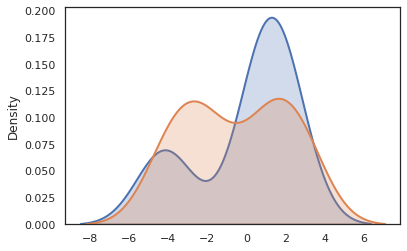

In [352]:
import seaborn as sns
sns.kdeplot(strength_stationary[2,3], linewidth=2, fill=True)
sns.kdeplot(strength_running[2,3], linewidth=2, fill=True)

In [353]:
print(ranksums( strength_stationary[2,3], strength_running[2,3] ) )

RanksumsResult(statistic=0.0, pvalue=1.0)


In [354]:
from scipy.stats import ranksums
from scipy import stats

for i, target_probe in enumerate(probe_list):
    for j, input_probe in enumerate(probe_list):
        res = ranksums( strength_stationary[i,j], strength_running[i,j] )
        if res[1]<=0.05/30 and i!=j:
            print(f"{input_probe}->{target_probe}: {res[1]}")

probeF->probeA: 0.0007215393720029193
probeF->probeB: 0.0007215393720029193


# With time warping

In [325]:
### Get time shifts (time warping parameters)
fix_shifts_stationary_all = {}
fix_shifts_running_all = {}


max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':10, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 1e-2

for target_probe in tqdm(probe_list):

    ########## Nothing need to be changed below
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    # model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], method='mine', verbose=False, 
    #                                            max_iter=max_iter, penalty=penalty)
    model_stationary.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                               max_iter=max_iter, penalty=penalty)

    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='mine', verbose=False, 
                                            max_iter=max_iter, penalty=penalty)

    fix_shifts_stationary_all[target_probe] = model_stationary.shifts
    fix_shifts_running_all[target_probe] = model_running.shifts

100%|█████████████████████████████████████████████| 6/6 [03:18<00:00, 33.10s/it]


In [326]:
from collections import defaultdict
strength_stationary = defaultdict(list)
strength_running = defaultdict(list)

for i, target_probe in enumerate(probe_list):
    for neuron in tqdm(cross_pop_list_all[target_probe]):

        max_iter = 10
        tau = 15
        coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
        num_basis_baseline = 20
        penalty = 1e-2
        
        ### Stationary
        select_trials = V1.stationary_trial_index
        model_stationary = GLM.PP_GLM(dataset=V1, 
                               select_trials=select_trials, 
                               membership=membership, 
                               condition_ids=condition_ids)
        model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                spike_train_ind = spike_train_ind_dict[input_neuron]
                model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], 
                                            **coupling_filter_params, apply_no_penalty=False)
        model_stationary.add_effect('trial_coef')
        model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], 
                               method='mine', 
                               verbose=False, 
                               max_iter=max_iter, 
                               fix_shifts=fix_shifts_stationary_all[target_probe], 
                               penalty=penalty, 
                               no_penalty_term_penalty=1e-2)
        filters = model_stationary.get_filter()
        k = 0
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                k += 1
                strength = np.sum(filters[k])
                strength_stationary[i,j].append(strength)
        
        ### Running
        select_trials = V1.running_trial_index
        model_running = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                spike_train_ind = spike_train_ind_dict[input_neuron]
                model_running.add_effect('coupling', spike_train_ind[:,select_trials], 
                                            **coupling_filter_params, apply_no_penalty=False)
        model_running.add_effect('trial_coef')
        model_running.fit_time_warping_baseline(spike_train_ind[:,select_trials], 
                           method='mine', 
                           verbose=False, 
                           max_iter=max_iter, 
                           fix_shifts=fix_shifts_running_all[target_probe], 
                           penalty=penalty, 
                           no_penalty_term_penalty=1e-2)
        filters = model_running.get_filter()
        k = 0
        for j, input_probe in enumerate(probe_list):
            for input_neuron in cross_pop_list_all[input_probe]:
                k += 1
                strength = np.sum(filters[k])
                strength_running[i,j].append(strength)
        

100%|█████████████████████████████████████████████| 4/4 [00:08<00:00,  2.18s/it]


<AxesSubplot:ylabel='Density'>

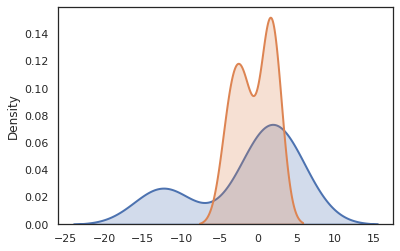

In [327]:
import seaborn as sns
sns.kdeplot(strength_stationary[2,3], linewidth=2, fill=True)
sns.kdeplot(strength_running[2,3], linewidth=2, fill=True)

In [328]:
print(ranksums( strength_stationary[2,3], strength_running[2,3] ) )

RanksumsResult(statistic=0.3768891807222045, pvalue=0.7062559621048525)


In [329]:
from scipy.stats import ranksums
from scipy import stats

for i, target_probe in enumerate(probe_list):
    for j, input_probe in enumerate(probe_list):
        res = ranksums( strength_stationary[i,j], strength_running[i,j] )
        if res[1]<=0.01 and i!=j:
            print(f"{input_probe}->{target_probe}: {res[1]}")

probeE->probeA: 0.0011298248105825034
probeF->probeA: 0.006830255863044082


# Each condition as a session

Tried: 
- using 'fix' function without time warping
- using 'fit_time_warping_baseline' function with trained peak times. 
- 

In [379]:
### Get the id of neurons that are classified as cross-pop
stimulus_condition_id = [275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270]
cross_pop_list_all = {}
probe_list = V1.selected_probes
for target_probe in probe_list:
    cross_pop_list = []
    cross_pop_conditions = {}
    for neuron in membership[0].index:
        if membership[1].loc[neuron]['probe'] == target_probe:
            for i, member in enumerate(membership):
                if member.loc[neuron]['group_id'] == 0:
                    if condition_ids[i] in stimulus_condition_id:
                        if neuron not in cross_pop_conditions:
                            cross_pop_list.append(neuron)
                            cross_pop_conditions[neuron] = [condition_ids[i]]
                        else:
                            cross_pop_conditions[neuron].append(condition_ids[i])
    major_cross_pop_list = []
    for neuron in cross_pop_list:
        if len(cross_pop_conditions[neuron])>= 1:
            major_cross_pop_list.append(neuron)
    cross_pop_list_all[target_probe] = major_cross_pop_list

In [380]:
spike_train_ind_dict = {}
for target_probe in probe_list:
    for neuron in cross_pop_list_all[target_probe]:
        # Get spike train of the neuron first
        spike_train_ind = np.zeros((V1.nt+V1.npadding, V1.spike_train.shape[1]))
        for itrial in range(V1.spike_train.shape[1]):
            spike_train_ind[:,itrial] = V1.spike_train.loc[neuron, V1.spike_train.columns[itrial]]
        spike_train_ind_dict[neuron] = spike_train_ind
    

In [432]:
from collections import defaultdict
strength_stationary = defaultdict(list)
strength_running = defaultdict(list)
probe_list = V1.selected_probes
condition_list = V1.presentation_table['stimulus_condition_id'].values

USE_WARPING = False
max_iter = 3
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 5
penalty = 1e5

for i, current_condition in enumerate(stimulus_condition_id):
    
    current_membership = membership[np.where(np.array(condition_ids)==current_condition)[0][0]]
    trials_in_this_condition = condition_list==current_condition
    cross_pop_list_all = {}
    
    for target_probe in probe_list:
        cross_pop_list = []
        cross_pop_conditions = {}
        for neuron in current_membership.index:
            if current_membership.loc[neuron]['probe'] == target_probe and \
                current_membership.loc[neuron]['group_id'] == 0:
                    cross_pop_list.append(neuron)
        cross_pop_list_all[target_probe] = cross_pop_list
    
    for i, target_probe in tqdm(enumerate(probe_list)):
        for neuron in cross_pop_list_all[target_probe]:

            ### Stationary
            select_trials = np.logical_and(V1.stationary_trial_index, trials_in_this_condition)
            if select_trials.sum()>=0 and select_trials.sum()<=15:
                model_stationary = GLM.PP_GLM(dataset=V1, 
                                       select_trials=select_trials, 
                                       membership=membership, 
                                       condition_ids=condition_ids)
                model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
                for j, input_probe in enumerate(probe_list):
                    for input_neuron in cross_pop_list_all[input_probe]:
                        spike_train_ind = spike_train_ind_dict[input_neuron]
                        model_stationary.add_effect('coupling', spike_train_ind[:,select_trials], 
                                                    **coupling_filter_params, apply_no_penalty=False)
                model_stationary.add_effect('trial_coef')
                if USE_WARPING:
                    model_stationary.fit_time_warping_baseline(spike_train_ind[:,select_trials], 
                                           method='mine', 
                                           verbose=False, 
                                           penalty=penalty, 
                                           max_iter=max_iter,
                                           fix_shifts=fix_shifts_running_all[target_probe], 
                                           no_penalty_term_penalty=penalty)
                else:
                    model_stationary.fit(spike_train_ind[:,select_trials], 
                                           method='mine', 
                                           verbose=False, 
                                           penalty=penalty, 
                                           no_penalty_term_penalty=penalty)
                filters = model_stationary.get_filter()
                k = 0
                for j, input_probe in enumerate(probe_list):
                    for input_neuron in cross_pop_list_all[input_probe]:
                        k += 1
                        strength = np.mean(filters[k])
                        strength_stationary[i,j].append(strength)

            ### Running
            select_trials = np.logical_and(V1.running_trial_index, trials_in_this_condition)
            if select_trials.sum()>=0 and select_trials.sum()<=15:
                model_running = GLM.PP_GLM(dataset=V1, 
                                   select_trials=select_trials, 
                                   membership=membership, 
                                   condition_ids=condition_ids)
                model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=False)
                for j, input_probe in enumerate(probe_list):
                    for input_neuron in cross_pop_list_all[input_probe]:
                        spike_train_ind = spike_train_ind_dict[input_neuron]
                        model_running.add_effect('coupling', spike_train_ind[:,select_trials], 
                                                    **coupling_filter_params, apply_no_penalty=False)
                model_running.add_effect('trial_coef')
                if USE_WARPING:
                    model_running.fit_time_warping_baseline(spike_train_ind[:,select_trials], 
                                       method='mine', 
                                       verbose=False, 
                                       max_iter=max_iter,
                                       fix_shifts=fix_shifts_running_all[target_probe], 
                                       penalty=penalty, 
                                       no_penalty_term_penalty=penalty)
                else:
                    model_running.fit(spike_train_ind[:,select_trials], 
                                           method='mine', 
                                           verbose=False, 
                                           penalty=penalty, 
                                           no_penalty_term_penalty=penalty)
                filters = model_running.get_filter()
                k = 0
                for j, input_probe in enumerate(probe_list):
                    for input_neuron in cross_pop_list_all[input_probe]:
                        k += 1
                        strength = np.mean(filters[k])
                        strength_running[i,j].append(strength)
        

6it [00:16,  2.81s/it]
6it [00:19,  3.29s/it]
6it [00:27,  4.57s/it]
6it [00:23,  3.94s/it]
6it [00:18,  3.11s/it]
6it [00:11,  1.94s/it]
6it [00:16,  2.79s/it]
6it [00:16,  2.83s/it]
6it [00:17,  2.94s/it]
6it [00:10,  1.77s/it]
6it [00:15,  2.58s/it]
6it [00:20,  3.41s/it]
6it [00:18,  3.03s/it]
6it [00:23,  3.95s/it]


<AxesSubplot:ylabel='Density'>

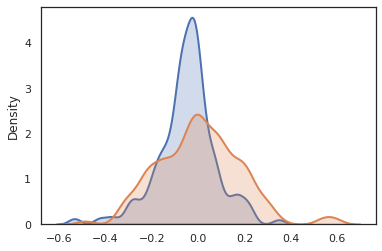

In [429]:
import seaborn as sns
sns.kdeplot(strength_stationary[2,3], linewidth=2, fill=True)
sns.kdeplot(strength_running[2,3], linewidth=2, fill=True)

In [430]:
print(ranksums( strength_stationary[2,3], strength_running[2,3] ) )

RanksumsResult(statistic=-11.814116658524355, pvalue=3.299990507595601e-32)


In [431]:
from scipy.stats import ranksums
from scipy import stats

for i, target_probe in enumerate(probe_list):
    for j, input_probe in enumerate(probe_list):
        res = ranksums( strength_stationary[i,j], strength_running[i,j] )
        if res[1]<=0.01 and i!=j:
            print(f"{input_probe}->{target_probe}: {res[1]}")

probeB->probeA: 7.355643083978575e-05
probeC->probeA: 6.508627360405087e-30
probeD->probeA: 1.064047285635017e-16
probeE->probeA: 5.0739959919841145e-23
probeF->probeA: 2.0643013604294115e-05
probeA->probeB: 1.3682303313840629e-37
probeC->probeB: 5.144678851111126e-47
probeD->probeB: 1.2255530743128925e-22
probeE->probeB: 1.7494421960077616e-33
probeF->probeB: 3.7359113508659974e-07
probeA->probeC: 1.2811540568699995e-33
probeB->probeC: 2.2669320535006953e-12
probeD->probeC: 3.299990507595601e-32
probeE->probeC: 3.413694152482797e-35
probeF->probeC: 6.681558873252583e-11
probeA->probeD: 8.314468333495169e-23
probeB->probeD: 7.382773095043623e-05
probeC->probeD: 1.5028917935160067e-31
probeE->probeD: 2.7701244844827635e-18
probeF->probeD: 0.00614711427340104
probeA->probeE: 2.5818884141340562e-17
probeB->probeE: 7.981688733361885e-07
probeC->probeE: 2.6605011168780167e-24
probeD->probeE: 5.5092955051344335e-11
probeF->probeE: 0.0067054261370030335
probeA->probeF: 1.4150514709739548e-21
